In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

def calculate_metrics(true_out, predict_out):
    true_out = np.array(true_out).ravel()
    predict_out = np.array(predict_out).ravel()
    N = len(predict_out)
    
    MSE = np.mean((predict_out - true_out) ** 2)
    RMSE = np.sqrt(MSE)
    MAE = np.mean(np.abs(predict_out - true_out))
    MBE = np.mean(predict_out - true_out)
    MAPE = np.mean(np.abs((true_out - predict_out) / true_out)) * 100
    
    numerator = np.sqrt(np.mean((true_out - predict_out) ** 2))
    denominator = np.sqrt(np.mean((true_out) ** 2)) + np.sqrt(np.mean((predict_out) ** 2))
    TIC = numerator / denominator if denominator != 0 else 0.0

    correlation_matrix = np.corrcoef(true_out, predict_out)
    R = correlation_matrix[0, 1] if not np.isnan(correlation_matrix[0,1]) else 0.0
    
    SS_res = np.sum((true_out - predict_out) ** 2)
    SS_tot = np.sum((true_out - np.mean(true_out)) ** 2)
    R2 = 1 - (SS_res / SS_tot) if SS_tot != 0 else 0.0
    
    return MSE, RMSE, MBE, MAE, MAPE, TIC, R, R2

# Load data
all_data = pd.read_csv('processed_dataset.csv', header=None)
input_all_data = all_data.iloc[:, :-1].values
output_all_data = all_data.iloc[:, -1].values

input_scaler = MinMaxScaler(feature_range=(-1, 1))
output_scaler = MinMaxScaler(feature_range=(-1, 1))

input_all_data = input_scaler.fit_transform(input_all_data)
output_all_data = output_scaler.fit_transform(output_all_data.reshape(-1, 1)).ravel()

train_ratio = 0.7
validate_ratio = 0.15
test_ratio = 0.15

num_samples = input_all_data.shape[0]
indices = np.arange(num_samples)
np.random.shuffle(indices)

train_end = int(round(train_ratio * num_samples))
validation_end = train_end + int(round(validate_ratio * num_samples))

train_idx = indices[:train_end]
validation_idx = indices[train_end:validation_end]
test_idx = indices[validation_end:]

input_train = input_all_data[train_idx, :]
output_train = output_all_data[train_idx]
input_validation = input_all_data[validation_idx, :]
output_validation = output_all_data[validation_idx]
input_test = input_all_data[test_idx, :]
output_test = output_all_data[test_idx]

# Placeholder for ANFIS model
# Replace with actual ANFIS training and prediction code
mean_output = np.mean(output_train)
output_pred_train = np.full_like(output_train, mean_output)
output_pred_val = np.full_like(output_validation, mean_output)
output_pred_test = np.full_like(output_test, mean_output)

output_train_denorm = output_scaler.inverse_transform(output_train.reshape(-1, 1)).ravel()
output_validation_denorm = output_scaler.inverse_transform(output_validation.reshape(-1, 1)).ravel()
output_test_denorm = output_scaler.inverse_transform(output_test.reshape(-1, 1)).ravel()

output_pred_train_denorm = output_scaler.inverse_transform(output_pred_train.reshape(-1, 1)).ravel()
output_pred_val_denorm = output_scaler.inverse_transform(output_pred_val.reshape(-1, 1)).ravel()
output_pred_test_denorm = output_scaler.inverse_transform(output_pred_test.reshape(-1, 1)).ravel()


phase 1
TrainData MSE=4742516.0474 RMSE=2177.7319 MBE=-0.0000 MAE=454.8669 TIC=0.8953 R=-0.0000 R2=-0.0000


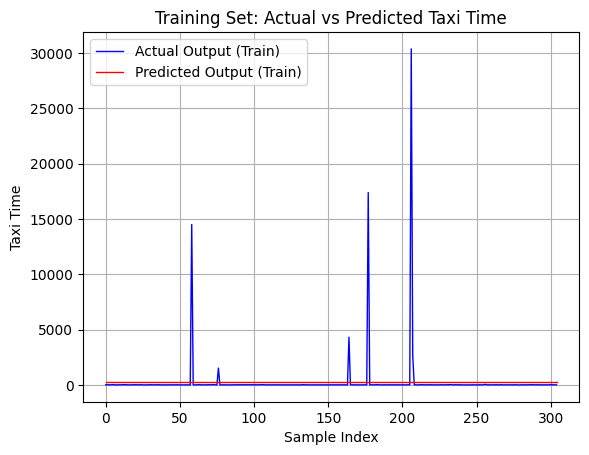

In [15]:
plt.figure()
plt.plot(output_train_denorm, 'b', linewidth=1, label='Actual Output (Train)')
plt.plot(output_pred_train_denorm, 'r', linewidth=1, label='Predicted Output (Train)')
plt.legend()
plt.xlabel('Sample Index')
plt.ylabel('Taxi Time')
plt.title('Training Set: Actual vs Predicted Taxi Time')
plt.grid(True)
print ('phase 1')

MSE, RMSE, MBE, MAE, MAPE, TIC, R, R2 = calculate_metrics(output_train_denorm, output_pred_train_denorm)
print(f'TrainData MSE={MSE:.4f} RMSE={RMSE:.4f} MBE={MBE:.4f} MAE={MAE:.4f} TIC={TIC:.4f} R={R:.4f} R2={R2:.4f}')

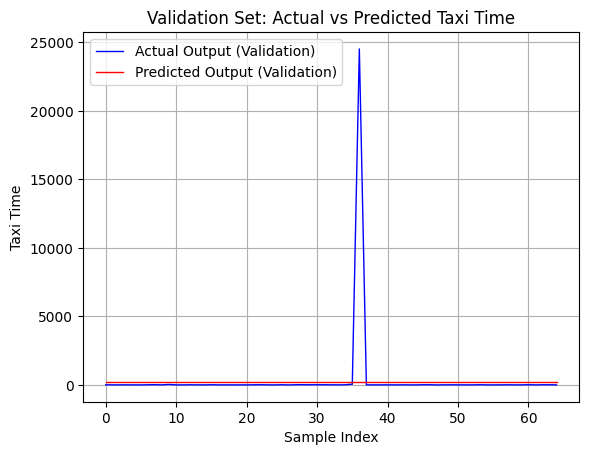

phase 2
ValData MSE=9125286.7975 RMSE=3020.8090 MBE=-144.4302 MAE=602.7448 TIC=0.9201 R=0.0000 R2=-0.0023


In [16]:
plt.figure()
plt.plot(output_validation_denorm, 'b', linewidth=1, label='Actual Output (Validation)')
plt.plot(output_pred_val_denorm, 'r', linewidth=1, label='Predicted Output (Validation)')
plt.legend()
plt.xlabel('Sample Index')
plt.ylabel('Taxi Time')
plt.title('Validation Set: Actual vs Predicted Taxi Time')
plt.grid(True)
plt.show()
print('phase 2')

MSE, RMSE, MBE, MAE, MAPE, TIC, R, R2 = calculate_metrics(output_validation_denorm, output_pred_val_denorm)
print(f'ValData MSE={MSE:.4f} RMSE={RMSE:.4f} MBE={MBE:.4f} MAE={MAE:.4f} TIC={TIC:.4f} R={R:.4f} R2={R2:.4f}')

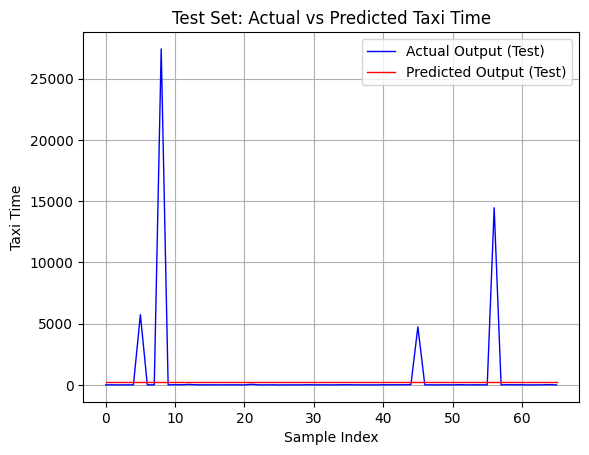

TestData MSE=15072396.1886 RMSE=3882.3184 MBE=-561.4981 MAE=995.8809 TIC=0.9320 R=-0.0000 R2=-0.0214
done


In [17]:
plt.figure()
plt.plot(output_test_denorm, 'b', linewidth=1, label='Actual Output (Test)')
plt.plot(output_pred_test_denorm, 'r', linewidth=1, label='Predicted Output (Test)')
plt.legend()
plt.xlabel('Sample Index')
plt.ylabel('Taxi Time')
plt.title('Test Set: Actual vs Predicted Taxi Time')
plt.grid(True)
plt.show()
 

MSE, RMSE, MBE, MAE, MAPE, TIC, R, R2 = calculate_metrics(output_test_denorm, output_pred_test_denorm)
print(f'TestData MSE={MSE:.4f} RMSE={RMSE:.4f} MBE={MBE:.4f} MAE={MAE:.4f} TIC={TIC:.4f} R={R:.4f} R2={R2:.4f}')
print('done')